In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 57.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c9e19f26266aa28a1588ec65ff3bf84755eee6ad5409f182e77f37e00fee4776
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


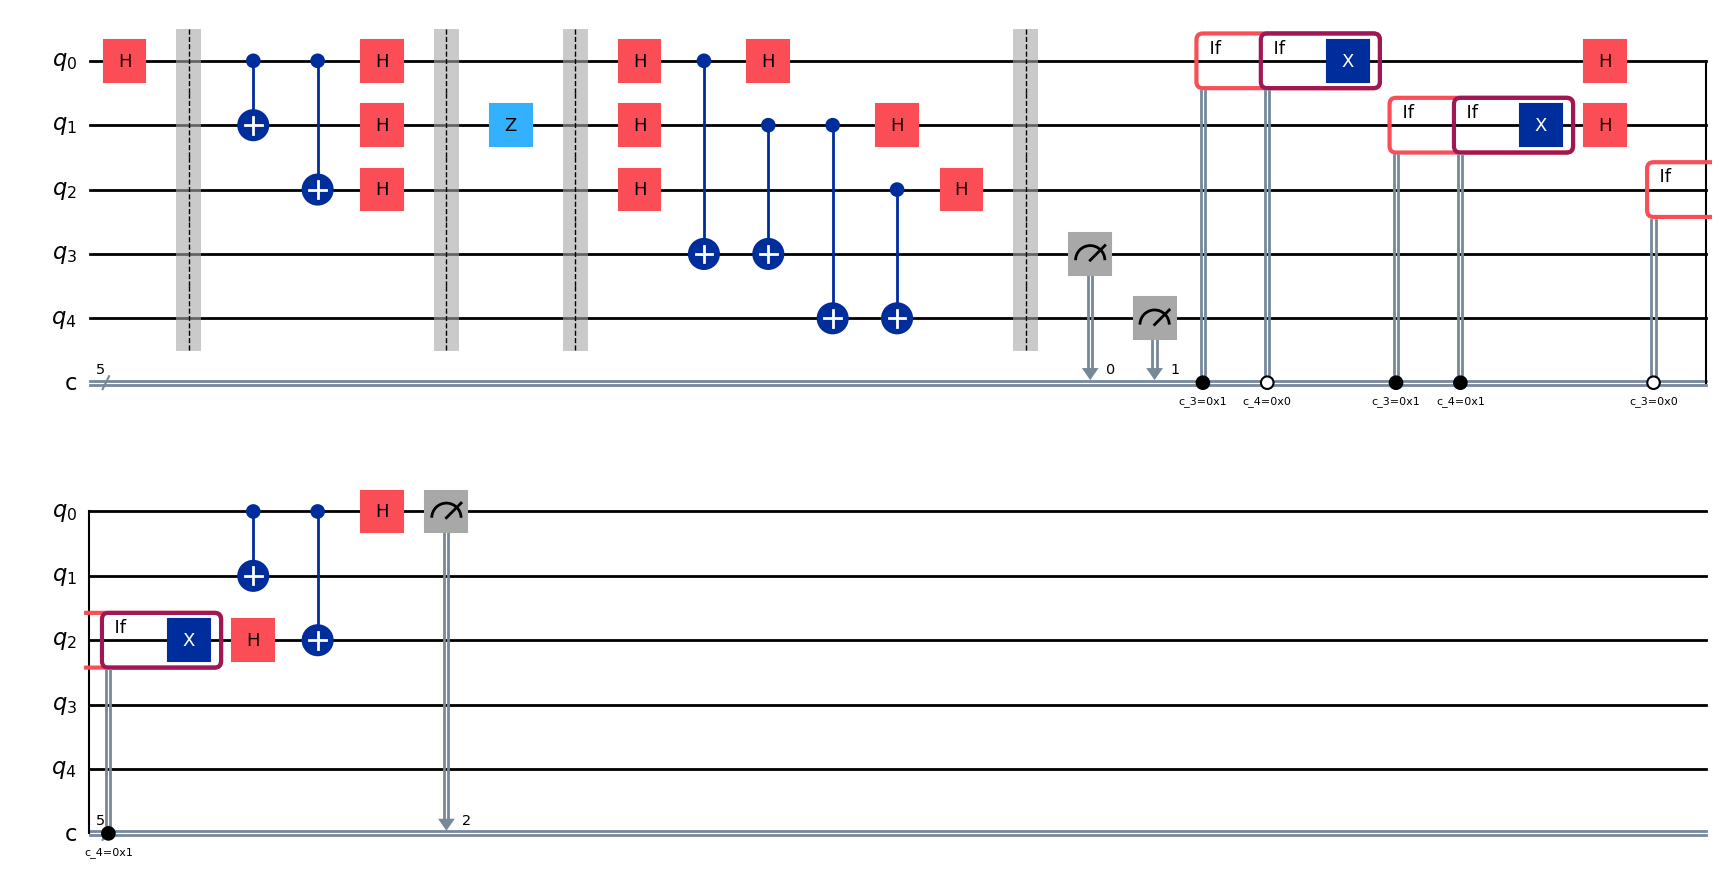

In [23]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.

# Create a 5-qubit quantum circuit and 5 classical bits
# Qubits 0, 1, 2 are for data encoding/correction.
# Qubits 3, 4 are for syndrome measurement ancillas.
# Classical bits 2, 3, 4 are for measurement results (corrected qubit, syndrome bits).
flip = QuantumCircuit(5, 5)

# Initialize the input qubit (q[0]) to |0> for testing
# Uncomment the line below to test with input |1>
# flip.x(0)

# --- Encoding Phase-Flip Code ---
# The phase-flip code encodes a single qubit state |psi> into a three-qubit state
# (alpha|+++> + beta|--->) by applying Hadamards and CNOTs.
# This converts Z-errors into X-errors in the Hadamard basis.
# 1. Apply Hadamard to the data qubit (q[0])
# 2. Use CNOT gates to entangle q[0] with q[1] and q[2],
#    effectively copying the state in the Hadamard basis.
flip.h(0)

flip.barrier()

flip.cx(0, 1)
flip.cx(0, 2)
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# --- Introduce Error (uncomment one section to test different scenarios) ---
# Single phase flip on qubit 0
# flip.z(0)

# Single phase flip on qubit 1
flip.z(1)

# Single phase flip on qubit 2
# flip.z(2)

# Two simultaneous phase flips (e.g., on q[0] and q[1])
# This should not be correctable by a 3-qubit code.
# flip.z(0)
# flip.z(1)

flip.barrier()

# --- Decoding Phase-Flip Code ---
# The decoding process involves converting Z errors to X errors, performing bit-flip correction,
# and then converting back.

# 1. Apply Hadamard gates to all three encoded qubits (0, 1, 2).
#    This transforms any phase-flip errors (Z gates) into bit-flip errors (X gates)
#    in the computational basis, making them detectable by a bit-flip syndrome circuit.
flip.h(0)
flip.h(1)
flip.h(2)

# 2. Perform syndrome measurement for bit-flip detection.
#    Qubit 3 acts as an ancilla to detect differences between q[0] and q[1].
#    Qubit 4 acts as an ancilla to detect differences between q[1] and q[2].
#    Syndrome q[3] = q[0] XOR q[1]
#    Syndrome q[4] = q[1] XOR q[2]
flip.cx(0, 3)
flip.cx(1, 3)
flip.cx(1, 4)
flip.cx(2, 4)

flip.h(0)
flip.h(1)
flip.h(2)
flip.barrier()

# 3. Measure ancilla qubits (3 and 4) to read out the syndrome bits.
#    These measurements are directed to classical bits 3 and 4.
flip.measure([3, 4], [0, 1])

# 4. Apply conditional corrections based on the measured syndrome bits.
#    The GenericBackendV2 supports control flow for dynamic circuits.
#    - Syndrome (c3, c4) = 00: No error (or undetectable double error) -> Do nothing.
#    - Syndrome (c3, c4) = 10: Error on q[0] -> Apply X to q[0].
#    - Syndrome (c3, c4) = 11: Error on q[1] -> Apply X to q[1].
#    - Syndrome (c3, c4) = 01: Error on q[2] -> Apply X to q[2].
c3 = flip.clbits[3]
c4 = flip.clbits[4]

# Syndrome 10: c3=1, c4=0 -> Error on q[0]
with flip.if_test((c3, 1)):
    with flip.if_test((c4, 0)):
        flip.x(0)

# Syndrome 11: c3=1, c4=1 -> Error on q[1]
with flip.if_test((c3, 1)):
    with flip.if_test((c4, 1)):
        flip.x(1)

# Syndrome 01: c3=0, c4=1 -> Error on q[2]
with flip.if_test((c3, 0)):
    with flip.if_test((c4, 1)):
        flip.x(2)

# For c3 == 0 AND c4 == 0 (Syndrome 00), do nothing, no if_test needed.

# 5. Apply Hadamard gates again to all three data qubits (0, 1, 2).
#    This rotates them back from the Hadamard basis to the computational basis,
#    converting the corrected X errors back to corrected Z errors.
flip.h(0)
flip.h(1)
flip.h(2)

flip.cx(0,1)
flip.cx(0,2)


# 6. Measure the corrected logical qubit (q[0]) onto classical bit 2.
#    The subsequent cell's `marginal_counts` indicates interest in classical bits 2, 3, and 4.
#    Here, c[2] represents the corrected logical state, and c[3], c[4] represent the syndrome bits
flip.h(0)
flip.measure(0, 2)


flip.draw("mpl")

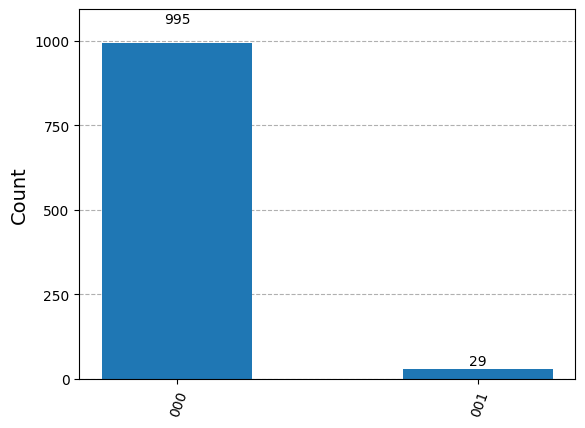

In [24]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)